In [2]:
"""
Reproduce the bar chart from the manuscript.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pingouin as pg
from scipy.stats import t as t_dist
from scipy import stats
import matplotlib.patches as patches
import seaborn as sns
# Paths relative to this script
# ROOT = Path.cwd()
# DATA = ROOT / "figures"
# FIGURES = ROOT / "figures"
# FIGURES.mkdir(exist_ok=True)
ROOT = Path.cwd()
DATA = ROOT / "figures"
colors = [(0, 48, 73),(214, 40, 40),(247, 127, 0),(252, 191, 73),(234, 226, 183),(148, 210, 189),
          (10, 147, 150),(17, 130, 0),]
colorz = []
for x in colors:
    colorz.append((x[0]/255,x[1]/255,x[2]/255))
    
colors1 = [(0, 48, 73),(214, 40, 40),(0, 48, 73),(214, 40, 40),(0, 48, 73),(214, 40, 40),
          (0, 48, 73),(214, 40, 40),]
colorz1 = []
for x in colors1:
    colorz1.append((x[0]/255,x[1]/255,x[2]/255))
    
def simple_beeswarm2(y, nbins=None, width=1.):
    """
    Returns x coordinates for the points in ``y``, so that plotting ``x`` and
    ``y`` results in a bee swarm plot.
    """
    y = np.asarray(y)
    if nbins is None:
        # nbins = len(y) // 6
        nbins = np.ceil(len(y) / 6).astype(int)
    # Get upper bounds of bins
    x = np.zeros(len(y))
    nn, ybins = np.histogram(y, bins=nbins)
    nmax = nn.max()
    #Divide indices into bins
    ibs = []#np.nonzero((y>=ybins[0])*(y<=ybins[1]))[0]]
    for ymin, ymax in zip(ybins[:-1], ybins[1:]):
        i = np.nonzero((y>ymin)*(y<=ymax))[0]
        ibs.append(i)
    # Assign x indices
    dx = width / (nmax // 2)
    for i in ibs:
        yy = y[i]
        if len(i) > 1:
            j = len(i) % 2
            i = i[np.argsort(yy)]
            a = i[j::2]
            b = i[j+1::2]
            x[a] = (0.5 + j / 3 + np.arange(len(b))) * dx
            x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx
    return x    

def dunnett_test(samples, control, alternative='two-sided'):
    """
    Manual implementation of Dunnett's test for comparing multiple 
    treatment groups against a single control group.
    
    Parameters:
    -----------
    samples : list of array_like
        List of treatment group samples
    control : array_like
        Control group sample
    alternative : str
        'two-sided', 'less', or 'greater'
    
    Returns:
    --------
    statistic : ndarray
        Test statistics for each treatment vs control
    pvalues : ndarray
        P-values for each treatment vs control
    """
    
    # Convert to arrays
    control = np.asarray(control)
    samples = [np.asarray(sample) for sample in samples]
    
    n_groups = len(samples) + 1  # +1 for control
    n_control = len(control)
    n_treatments = [len(s) for s in samples]
    
    # Group means
    mean_control = np.mean(control)
    means_treatments = [np.mean(s) for s in samples]
    
    # Variances for each group
    var_control = np.var(control, ddof=1)
    vars_treatments = [np.var(s, ddof=1) for s in samples]
    
    # Pooled variance (assuming equal variance across groups)
    # That's a key assumption of Dunnett's test
    all_values = np.concatenate([control] + samples)
    grand_mean = np.mean(all_values)
    
    # Calculate Mean Square Error (within-group variance)
    ss_within = 0
    df_within = 0
    for group in [control] + samples:
        ss_within += np.sum((group - np.mean(group))**2)
        df_within += len(group) - 1
    
    ms_within = ss_within / df_within
    
    # Calculate standard error for each comparison
    # SE = sqrt(MS_within * (1/n_control + 1/n_treatment))
    se_values = []
    for n_treat in n_treatments:
        se = np.sqrt(ms_within * (1/n_control + 1/n_treat))
        se_values.append(se)
    
    # Calculate t-statistics
    t_stats = []
    for mean_treat, se in zip(means_treatments, se_values):
        t_stat = (mean_treat - mean_control) / se
        t_stats.append(t_stat)
    
    # Critical values and p-values
    # For Dunnett's test, we need the t-distribution with df = df_within
    # and adjust for multiple comparisons
    
    if alternative == 'two-sided':
        # For two-sided test
        pvalues = [2 * (1 - t_dist.cdf(abs(t), df=df_within)) 
                   for t in t_stats]
    elif alternative == 'less':
        pvalues = [t_dist.cdf(t, df=df_within) for t in t_stats]
    elif alternative == 'greater':
        pvalues = [1 - t_dist.cdf(t, df=df_within) for t in t_stats]
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'")
    
    # Bonferroni correction for multiple comparisons (conservative)
    # For proper Dunnett, you'd use the specialized distribution,
    # but Bonferroni is a safe approximation
    pvalues_bonferroni = np.array(pvalues) * n_groups
    pvalues_bonferroni = np.minimum(pvalues_bonferroni, 1.0)
    
    return np.array(t_stats), pvalues_bonferroni

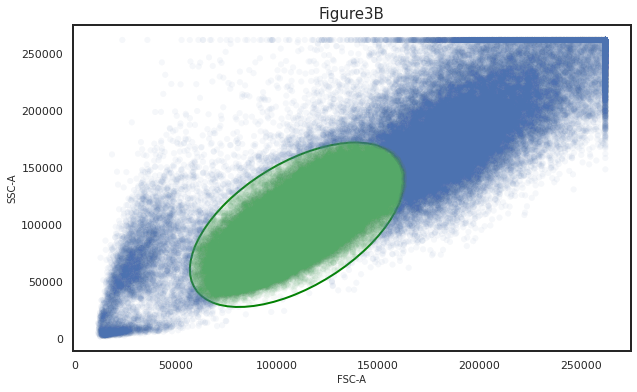

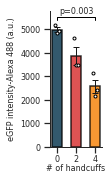

In [13]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig3B_data.parquet"
df = pd.read_parquet(Rawdata)

fig,ax = plt.subplots(figsize=(10,6))
x,y = df['FSC-A'], df['SSC-A']

# The ellipse
g_ell_center,g_ell_width,g_ell_height,angle = (110000, 100000),160000,80000,60.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle,sin_angle = np.cos(np.radians(180.-angle)),np.sin(np.radians(180.-angle))

xc,yc = x - g_ell_center[0],y - g_ell_center[1]

xct,yct = xc * cos_angle - yc * sin_angle,xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.05, alpha =0.05)
ax.set_title('Figure3B', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df = df.groupby('condition')['Alexa 488-A'].describe().T
df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[1:2]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[:-2]

t_stats, p_values = dunnett_test([df[df['group'] == '2']['value'],df[df['group'] == '4']['value']], 
                                  df[df['group'] == '0']['value'], alternative='two-sided')

w, x = 0.5, [1,2,3,] 
fig, ax = plt.subplots(figsize=(0.9375,2.5))
ax.bar(x,
       height=df.groupby('group')['value'].mean(),yerr=df.groupby('group')['value'].sem(),capsize=10,
       width=w,tick_label=[" ", " ", ' '],color=colorz,alpha = 0.8,edgecolor=(0,0,0,1),
       linewidth=1.5,error_kw=dict(lw=1, capsize=3, capthick=1))
x1 = simple_beeswarm2(df[df['group'] == '0']['value'], width=0.25)
ax.plot(x1+1., df[df['group'] == '0']['value'], '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == '2']['value'], width=0.25)
ax.plot(x2+2., df[df['group'] == '2']['value'], '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == '4']['value'], width=0.25)
ax.plot(x3+3., df[df['group'] == '4']['value'], '.', color ='w',markeredgecolor='black')
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
plt.yticks(fontsize=8,)
plt.ylabel('eGFP intensity-Alexa 488 (a.u.)',fontsize=8,)
tick_len,pad,pvp = 100,75,[5400,5500,5400,]
ax.plot([1, 1, 3, 3], [pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len], c="black",linewidth=1)
label2 = f"p={p_values[1]:.3f}"
ax.text(2, pvp[1] + pad, label2, fontsize=8, va="bottom", ha="center",)
ax.text(1, -700, "0", fontsize=8, va="bottom", ha="center")
ax.text(2, -700, "2", fontsize=8, va="bottom", ha="center")
ax.text(3, -700, "4", fontsize=8, va="bottom", ha="center")
ax.text(2, -1100, "# of handcuffs", fontsize=8, va="bottom", ha="center",)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "figures"
# outfile = FIGURES / "figure3B.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

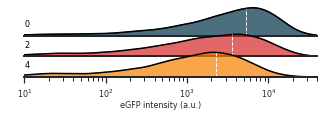

In [14]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig3B_data.parquet"
df = pd.read_parquet(Rawdata)
df = df.loc[(df['Alexa 488-A'] > 0)]

# fig,ax = plt.subplots(figsize=(5,5))
x,y = df['FSC-A'], df['SSC-A']

# The ellipse
g_ell_center,g_ell_width,g_ell_height,angle = (110000, 100000),160000,80000,60.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle,sin_angle = np.cos(np.radians(180.-angle)),np.sin(np.radians(180.-angle))

xc,yc = x - g_ell_center[0],y - g_ell_center[1]

xct,yct = xc * cos_angle - yc * sin_angle,xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('Figure3B', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
# plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
listoffiles = ['0L1','2L1','4L1',]
df = df[df['condition'].isin(listoffiles)]
df['condition'] = df['condition'].str[:-2]

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0), 'axes.linewidth':2})
palette = sns.color_palette("Set2", 12)
g = sns.FacetGrid(df, palette=colorz, row="condition", hue="condition",aspect=7, height=0.72)
g.set(xscale='log')
g.map_dataframe(sns.kdeplot, x="Alexa 488-A", fill=True, alpha=0.7)
g.map_dataframe(sns.kdeplot, x="Alexa 488-A", color='black',linewidth=1.5)
def label(x, color, label):
    ax = plt.gca()
#     plt.rcParams['font.family'] = 'DeJavu Serif'
#     plt.rcParams['font.serif'] = ['Arial']
    ax.text(0, .4, label, color='black', fontsize=8,ha="left", va="center", transform=ax.transAxes)
for derp, ax in enumerate(g.axes.flat):
    if derp == 0:
        ax.vlines(x=5260.241699, ymin=0, ymax=0.76, colors='#FFFFFF',ls='--', lw=1, alpha=1)
    if derp == 1:
        ax.vlines(x=3576.669922, ymin=0, ymax=0.62, colors='#FFFFFF',ls='--', lw=1, alpha=1)
    if derp == 2:
        ax.vlines(x=2263.556396, ymin=0, ymax=0.67, colors='#FFFFFF',ls='--', lw=1, alpha=1)
g.map(label, "condition")
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], xlabel=" ", ylabel=' ')
g.despine(left=True)
ax = plt.gca()
ax.tick_params(axis='x', which='both', bottom=True)
ax.set_xlim([10, 40000])
ax.xaxis.label.set_size(8)
# plt.suptitle('eGFP with locks', y=0.98, fontsize =6)
ax.xaxis.label.set_size(8)
ax.text(1500, -0.9, "eGFP intensity (a.u.)", fontsize=8, va="bottom", ha="right")
plt.xticks(fontsize=8)
# link = '/mnt/c/Users/ryanodine/Documents/Manuscripts/'
# plt.savefig('{0}figure2C.svg'.format(link), format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

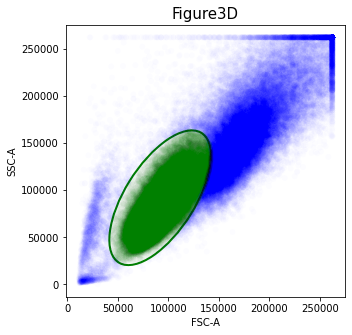

ANOVA Results:
   Source            SS  DF            MS          F     p-unc       np2
0   group  5.440708e+06   3  1.813569e+06  41.921699  0.000031  0.940194
1  Within  3.460870e+05   8  4.326087e+04        NaN       NaN       NaN
bonferoni tukey test
  Contrast     A      B  Paired  Parametric         T  dof alternative  \
0    group    Gm    GmC   False        True -9.742737  4.0   two-sided   
1    group    Gm   GmmC   False        True -4.855820  4.0   two-sided   
2    group    Gm  Gonly   False        True -7.278848  4.0   two-sided   
3    group   GmC   GmmC   False        True  8.194924  4.0   two-sided   
4    group   GmC  Gonly   False        True  1.458568  4.0   two-sided   
5    group  GmmC  Gonly   False        True -5.774272  4.0   two-sided   

      p-unc    p-corr p-adjust    BF10    hedges  
0  0.000622  0.003730     bonf  31.648 -6.363929  
1  0.008304  0.049826     bonf   5.705 -3.171808  
2  0.001893  0.011358     bonf  14.795 -4.754524  
3  0.001208  0.007248 

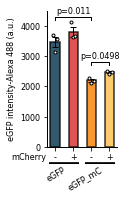

In [3]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig3D_data.parquet"
df = pd.read_parquet(Rawdata)
fig,ax = plt.subplots(figsize=(5,5))

x, y = df['FSC-A'], df['SSC-A']
# The ellipse
g_ell_center, g_ell_width, g_ell_height, angle = (92000, 92000), 160000, 70000, 60.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle, sin_angle = np.cos(np.radians(180.-angle)), np.sin(np.radians(180.-angle))

xc, yc = x - g_ell_center[0], y - g_ell_center[1]

xct, yct = xc * cos_angle - yc * sin_angle, xc * sin_angle + yc * cos_angle 
rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('Figure3D', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df = df.loc[(df['Alexa 488-A'] > 800)]

df = df.groupby('condition')['Alexa 488-A'].describe().T
df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[1:2]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[2:-1]
means, sems = df.groupby('group')['value'].mean(),df.groupby('group')['value'].sem()
order = ['Gonly', 'GmC', 'Gm', 'GmmC',]
means, sems = means.reindex(order), sems.reindex(order)

anova = pg.anova(data=df, dv='value', between='group', detailed=True) ### One-way ANOVA
tukey = pg.pairwise_tests(dv='value', between='group', data=df, padjust='bonf') ### Tukey HSD
print("ANOVA Results:"), print(anova), print('bonferoni tukey test'), print(tukey)

w, groups, x = 0.5,means.index.tolist(), [1,2,3,4]
fig, ax = plt.subplots(figsize=(1.25,2.5))
ax.bar(x,height=means,yerr=sems,capsize=10,width=w,tick_label=[" ", " ", ' ', ' ',],color=colorz,
       alpha = 0.8,edgecolor=(0,0,0,1),linewidth=1.5,error_kw=dict(lw=1, capsize=3, capthick=1))
x1 = simple_beeswarm2(df[df['group'] == 'Gonly']['value'], width=0.25)
ax.plot(x1+1., df[df['group'] == 'Gonly']['value'], '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == 'GmC']['value'], width=0.25)
ax.plot(x2+2., df[df['group'] == 'GmC']['value'], '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == 'Gm']['value'], width=0.25)
ax.plot(x3+3., df[df['group'] == 'Gm']['value'], '.', color ='w',markeredgecolor='black')
x4 = simple_beeswarm2(df[df['group'] == 'GmmC']['value'], width=0.25)
ax.plot(x4+4., df[df['group'] == 'GmmC']['value'], '.', color ='w',markeredgecolor='black')
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
plt.yticks(fontsize=8,)
plt.ylabel('eGFP intensity-Alexa 488 (a.u.)',fontsize=8,)
tick_len,pad,pvp = 100,50,[4500,2800,4300,]
# ax.plot([1, 1, 2, 2], [pvp[0] - tick_len, pvp[0], pvp[0], pvp[0] - tick_len], c="black",linewidth=1)
ax.plot([3, 3, 4, 4], [pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len], c="black",linewidth=1)
ax.plot([1, 1, 3, 3], [pvp[2] - tick_len, pvp[2], pvp[2], pvp[2] - tick_len], c="black",linewidth=1)
# label1 = f"p=ns" ### p_bonferroni=1.000000 
label2, label3 = f"p={tukey['p-corr'].iloc[1]:.3g}", f"p={tukey['p-corr'].iloc[2]:.3f}" 
# ax.text(1.5, pvp[0] + pad, label1, fontsize=8, va="bottom", ha="center",)
ax.text(3.5, pvp[1] + pad, label2, fontsize=8, va="bottom", ha="center",)
ax.text(2, pvp[2] + pad, label3, fontsize=8, va="bottom", ha="center",)
ax.text(0.5, -500, "mCherry", fontsize=8, va="bottom", ha="right")
ax.text(1, -500, "-", fontsize=8, va="bottom", ha="center")
ax.text(2, -500, "+", fontsize=8, va="bottom", ha="center")
ax.text(3, -500, "-", fontsize=8, va="bottom", ha="center")
ax.text(4, -500, "+", fontsize=8, va="bottom", ha="center")
ax.text(1.5, -575, "___", fontsize=20, va="bottom", ha="center",fontweight='bold')
ax.text(3.5, -575, "___", fontsize=20, va="bottom", ha="center",fontweight='bold')
ax.text(1.7, -1200, "eGFP", fontsize=8, va="bottom", ha="right",rotation=30)
ax.text(3.7, -1500, "eGFP_mC", fontsize=8, va="bottom", ha="right",rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "figures"
# outfile = FIGURES / "figure3D.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

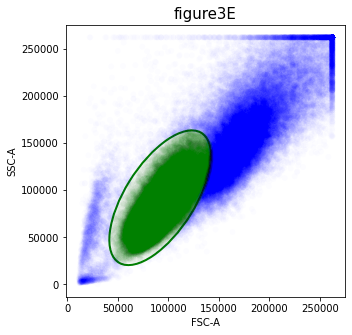

In [6]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig3D_data.parquet"
df = pd.read_parquet(Rawdata)
fig,ax = plt.subplots(figsize=(5,5))
# Some test points
x, y = df['FSC-A'], df['SSC-A']

# The ellipse
g_ell_center, g_ell_width, g_ell_height, angle = (92000, 92000), 160000, 70000, 60.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle, sin_angle = np.cos(np.radians(180.-angle)), np.sin(np.radians(180.-angle))

xc, yc = x - g_ell_center[0], y - g_ell_center[1]

xct, yct = xc * cos_angle - yc * sin_angle, xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('figure3E', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()

ANOVA Results:
   Source            SS  DF            MS          F     p-unc      np2
0   group  2.045541e+07   3  6.818470e+06  41.366743  0.000032  0.93944
1  Within  1.318638e+06   8  1.648298e+05        NaN       NaN      NaN
bonferoni tukey test
  Contrast     A      B  Paired  Parametric          T  dof alternative  \
0    group    Gm    GmC   False        True -10.691135  4.0   two-sided   
1    group    Gm   GmmC   False        True  -4.859973  4.0   two-sided   
2    group    Gm  Gonly   False        True  -4.948821  4.0   two-sided   
3    group   GmC   GmmC   False        True  12.084446  4.0   two-sided   
4    group   GmC  Gonly   False        True   4.188864  4.0   two-sided   
5    group  GmmC  Gonly   False        True  -2.038888  4.0   two-sided   

      p-unc    p-corr p-adjust    BF10    hedges  
0  0.000434  0.002602     bonf  40.719 -6.983420  
1  0.008279  0.049677     bonf   5.715 -3.174521  
2  0.007768  0.046606     bonf   5.946 -3.232556  
3  0.000269  0.001

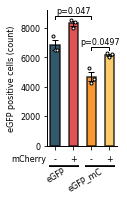

In [4]:
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df = df.loc[(df['Alexa 488-A'] > 825)]
df = df.groupby('condition')['Alexa 488-A'].describe().T
df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[:1]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[2:-1]
means, sems = df.groupby('group')['value'].mean(),df.groupby('group')['value'].sem()
order = ['Gonly', 'GmC', 'Gm', 'GmmC',]
means, sems =means.reindex(order), sems.reindex(order)
anova = pg.anova(data=df, dv='value', between='group', detailed=True) ### One-way ANOVA
tukey = pg.pairwise_tests(dv='value', between='group', data=df, padjust='bonf') ### Tukey HSD
print("ANOVA Results:"),print(anova),print('bonferoni tukey test'),print(tukey)

w, groups, x = 0.5,means.index.tolist(), [1,2,3,4]
fig, ax = plt.subplots(figsize=(1.25,2.5))
ax.bar(x,height=means,yerr=sems,capsize=10, width=w, tick_label=[" ", " ", ' ', ' ',],color=colorz,
       alpha = 0.8,edgecolor=(0,0,0,1),linewidth=1.5,error_kw=dict(lw=1, capsize=3, capthick=1))
x1 = simple_beeswarm2(df[df['group'] == 'Gonly']['value'], width=0.25)
ax.plot(x1+1., df[df['group'] == 'Gonly']['value'], '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == 'GmC']['value'], width=0.25)
ax.plot(x2+2., df[df['group'] == 'GmC']['value'], '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == 'Gm']['value'], width=0.25)
ax.plot(x3+3., df[df['group'] == 'Gm']['value'], '.', color ='w',markeredgecolor='black')
x4 = simple_beeswarm2(df[df['group'] == 'GmmC']['value'], width=0.25)
ax.plot(x4+4., df[df['group'] == 'GmmC']['value'], '.', color ='w',markeredgecolor='black')
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
plt.yticks(fontsize=8,)
plt.ylabel('eGFP positive cells (count)',fontsize=8,)
tick_len,pad,pvp  = 200, 50, [9000,6700,8800,]
ax.plot([3, 3, 4, 4], [pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len], c="black",linewidth=1)
ax.plot([1, 1, 3, 3], [pvp[2] - tick_len, pvp[2], pvp[2], pvp[2] - tick_len], c="black",linewidth=1)
label2,label3  = f"p={tukey['p-corr'].iloc[1]:.3g}", f"p={tukey['p-corr'].iloc[2]:.3f}" 
ax.text(3.5, pvp[1] + pad, label2, fontsize=8, va="bottom", ha="center",)
ax.text(2, pvp[2] + pad, label3, fontsize=8, va="bottom", ha="center",)
ax.text(0.5, -1200, "mCherry", fontsize=8, va="bottom", ha="right")
ax.text(1, -1200, "-", fontsize=8, va="bottom", ha="center")
ax.text(2, -1200, "+", fontsize=8, va="bottom", ha="center")
ax.text(3, -1200, "-", fontsize=8, va="bottom", ha="center")
ax.text(4, -1200, "+", fontsize=8, va="bottom", ha="center")
ax.text(1.5, -1400, "___", fontsize=20, va="bottom", ha="center",fontweight='bold')
ax.text(3.5, -1400, "___", fontsize=20, va="bottom", ha="center",fontweight='bold')
ax.text(1.7, -2600, "eGFP", fontsize=8, va="bottom", ha="right",rotation=30)
ax.text(3.7, -3200, "eGFP_mC", fontsize=8, va="bottom", ha="right",rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "figures"
# outfile = FIGURES / "figure3E.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


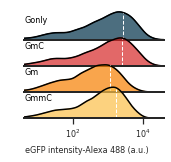

In [21]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig3D_data.parquet"
df = pd.read_parquet(Rawdata)
df = df.loc[(df['Alexa 488-A'] > 0)]

# fig,ax = plt.subplots(figsize=(5,5))
x,y = df['FSC-A'], df['SSC-A']

# The ellipse
g_ell_center,g_ell_width,g_ell_height,angle = (110000, 100000),160000,80000,60.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle,sin_angle = np.cos(np.radians(180.-angle)),np.sin(np.radians(180.-angle))

xc,yc = x - g_ell_center[0],y - g_ell_center[1]

xct,yct = xc * cos_angle - yc * sin_angle,xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('Figure3C', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
# plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
listoffiles = ['K_Gonly1', 'K_GmC1','K_Gm3','K_GmmC1',]
df = df[df['condition'].isin(listoffiles)]
df['condition'] = df['condition'].str[2:-1]

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0), 'axes.linewidth':2})
g = sns.FacetGrid(df, palette=colorz, row="condition", hue="condition", aspect=4.5, height=0.6)
g.set(xscale='log')
g.map_dataframe(sns.kdeplot, x="Alexa 488-A", fill=True, alpha=0.7)
g.map_dataframe(sns.kdeplot, x="Alexa 488-A", color='black',linewidth=1.5)
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .6, label, color='black', fontsize=8,ha="left", va="center", transform=ax.transAxes)
for derp, ax in enumerate(g.axes.flat):
    if derp == 0:
        ax.vlines(x=2730, ymin=0, ymax=0.55, colors='#FFFFFF',ls='--', lw=1, alpha=1)
    if derp == 1:
        ax.vlines(x=2480, ymin=0, ymax=0.55, colors='#FFFFFF',ls='--', lw=1, alpha=1)
    if derp == 2:
        ax.vlines(x=1123, ymin=0, ymax=0.55, colors='#FFFFFF',ls='--', lw=1, alpha=1)
    if derp == 3:
        ax.vlines(x=1720, ymin=0, ymax=0.61, colors='#FFFFFF',ls='--', lw=1, alpha=1)
g.map(label, "condition")
g.fig.subplots_adjust(hspace=-.2)
g.set_titles("")
g.set(yticks=[], xlabel=" ",ylabel=' ')
g.despine( left=True)
ax = plt.gca()
ax.tick_params(axis='x', which='both', bottom=True)
ax.set_xlim([4, 40000])
ax.xaxis.label.set_size(8)
ax.text(15000, -0.75, "eGFP intensity-Alexa 488 (a.u.)", fontsize=8, va="bottom", ha="right",)
plt.xticks(fontsize=8)
# FIGURES = ROOT / "figures"
# outfile = FIGURES / "figure3C.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()